# Exploratory Data Analysis - Fundação Pão dos Pobres

This notebook performs an Exploratory Data Analysis (EDA) on the processed LEM (Livro de Escrituração Mensal) data. 
The goal is to understand the dataset characteristics, identify insights, and define business questions for the visualization dashboard.

## 1. Project Context
**Objective:** Develop interactive visualization solutions to support decision-making for Fundação Pão dos Pobres.
**Target Columns:** `tipo`, `area`, `mes`, `ano`, `valor`, `arquivo`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load data
df = pd.read_csv('../data/output/processed.csv')

# Map months to numbers for sorting
month_map = {
    'JAN': 1, 'FEV': 2, 'MAR': 3, 'ABR': 4, 'MAI': 5, 'JUN': 6,
    'JUL': 7, 'AGO': 8, 'SET': 9, 'OUT': 10, 'NOV': 11, 'DEZ': 12
}
df['mes_num'] = df['mes'].map(month_map)
df = df.sort_values(['ano', 'mes_num'])

df.head()

,tipo,area,mes,ano,valor,arquivo,mes_num
0,Atendimentos indvidual,desdobramentos tecnicos,JAN,2021,40.0,LEM_2021.xlsx,1
12,Atedimento familiar,desdobramentos tecnicos,JAN,2021,31.0,LEM_2021.xlsx,1
24,Interface com rede socioassistencial,desdobramentos tecnicos,JAN,2021,10.0,LEM_2021.xlsx,1
36,Interface com judiciário,desdobramentos tecnicos,JAN,2021,8.0,LEM_2021.xlsx,1
48,PIAS / Relatórios,educacao,JAN,2021,17.0,LEM_2021.xlsx,1


## 2. Data Description and Quality
Checking for missing values, data types, and general statistics.

In [2]:
print("### Info")
print(df.info())

print("\n### Missing Values")
print(df.isnull().sum())

print("\n### Distinct Areas")
print(df['area'].unique())

print("\n### Value Statistics")
print(df['valor'].describe())

### Info
<class 'pandas.core.frame.DataFrame'>
Index: 2040 entries, 0 to 2039
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tipo     2040 non-null   object 
 1   area     2040 non-null   object 
 2   mes      2040 non-null   object 
 3   ano      2040 non-null   int64  
 4   valor    2040 non-null   float64
 5   arquivo  2040 non-null   object 
 6   mes_num  2040 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 127.5+ KB
None

### Missing Values
tipo       0
area       0
mes        0
ano        0
valor      0
arquivo    0
mes_num    0
dtype: int64

### Distinct Areas
['desdobramentos tecnicos' 'educacao' 'profissionalizacao' 'saude']

### Value Statistics
count    2040.000000
mean        6.039706
std        11.863615
min         0.000000
25%         0.000000
50%         0.000000
75%         7.000000
max        87.000000
Name: valor, dtype: float64


## 3. Visual Exploratory Analysis

### 3.1 Distribution of Values by Area
How are the records distributed across the four main areas?

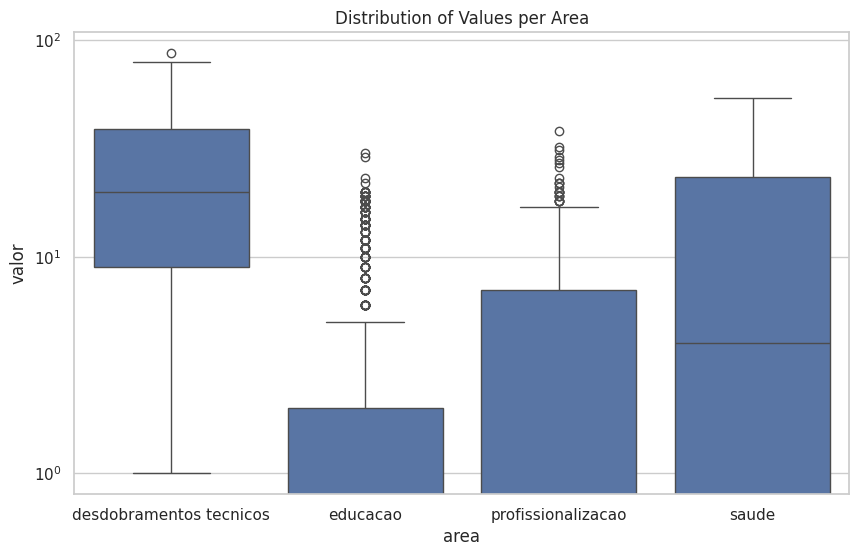

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='area', y='valor')
plt.title('Distribution of Values per Area')
plt.yscale('log') # Log scale due to high variance in types
plt.show()

### 3.2 Temporal Analysis - Total atendimentos over years
Let's look at the evolution of the volume of records over time.

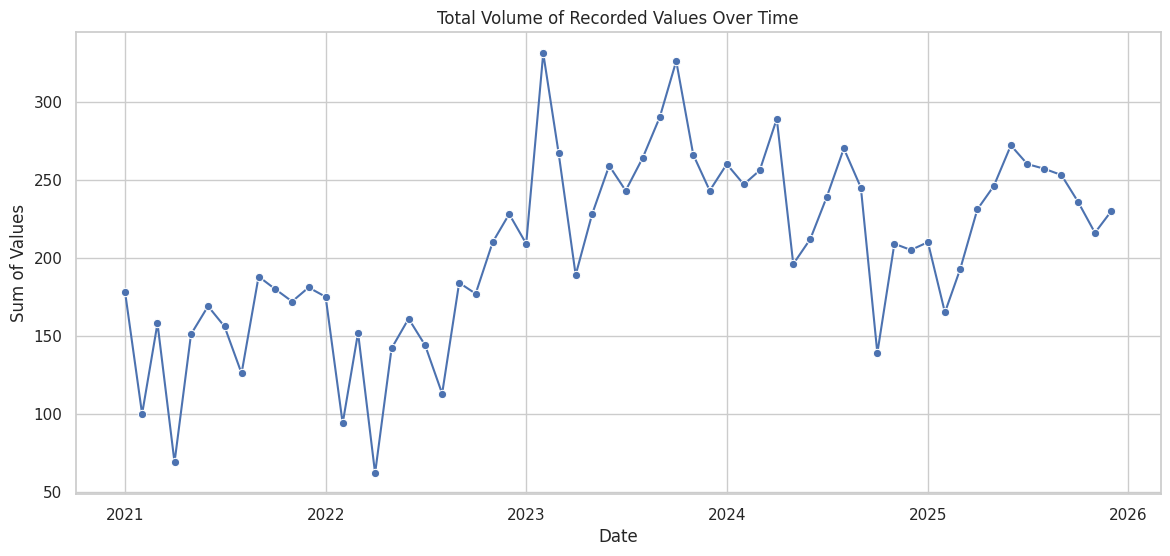

In [4]:
temporal_df = df.groupby(['ano', 'mes_num'])['valor'].sum().reset_index()
temporal_df['date'] = pd.to_datetime(temporal_df['ano'].astype(str) + '-' + temporal_df['mes_num'].astype(str) + '-01')

plt.figure(figsize=(14, 6))
sns.lineplot(data=temporal_df, x='date', y='valor', marker='o')
plt.title('Total Volume of Recorded Values Over Time')
plt.ylabel('Sum of Values')
plt.xlabel('Date')
plt.show()

### 3.3 Specific Insights: Education (Education Area)
Analysis of "matriculados" vs "aguardando vaga".

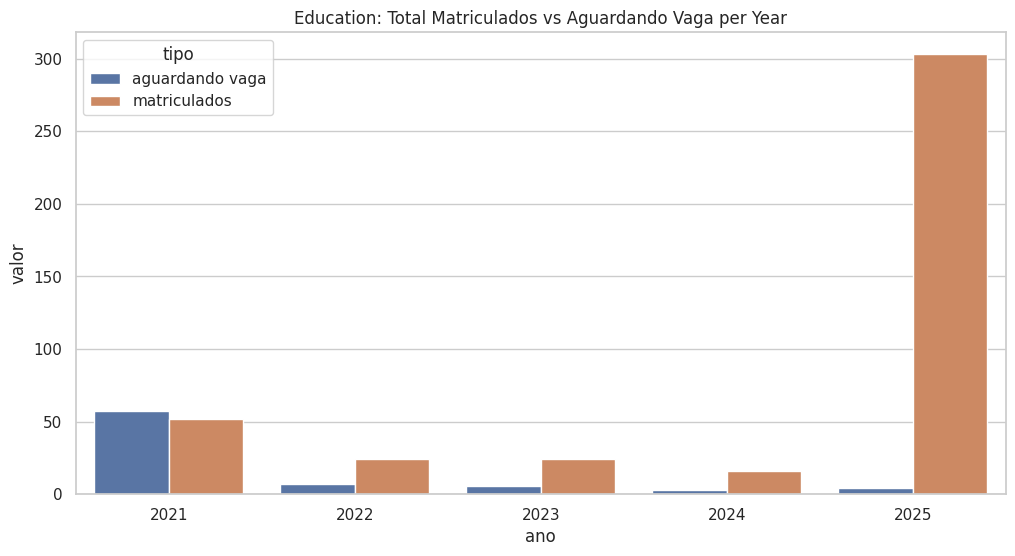

In [5]:
edu_compare = df[df['tipo'].isin(['matriculados', 'aguardando vaga'])]
edu_sum = edu_compare.groupby(['ano', 'tipo'])['valor'].sum().reset_index()

sns.barplot(data=edu_sum, x='ano', y='valor', hue='tipo')
plt.title('Education: Total Matriculados vs Aguardando Vaga per Year')
plt.show()

## 4. Business Questions

Based on the preliminary analysis, we define the following business questions:

1. **Analysis of Occupancy:** How has the average number of "Efetivos na casa" evolved across different years and months, and are there periods of peak occupancy?
2. **Health Impact:** What is the correlation between "Saúde Mental" atendimentos and other technical desdobramentos over time?
3. **Education Efficiency:** What is the monthly ratio of students "aguardando vaga" compared to those "matriculados", and is the foundation managing to reduce this waiting list?
4. **Professional Integration:** How effective is the transition from "ENCAMINHADOS para mercado de trabalho" to actual "INSERIDO no mercado de trabalho"?

## 5. Proposed Dashboard Specification (Part II)

**Environment:** Streamlit

**Proposed Visualizations:**
- **Heatmap (Monthly vs Type):** To identify seasonal patterns in service demand (e.g., higher volume of social assistance in specific months).
- **Stacked Area Chart (Temporal):** To show the composition of total activities by area (Saúde, Educação, etc.) over time.
- **Indicator Cards (KPIs):** Real-time summary of current total "Efetivos", "Matriculados", and "Inseridos no mercado de trabalho".
- **Clustered Bar Chart:** Comparative analysis between years for specific targets like "Novos ingressos" vs "Desligamentos".